In [1]:
# ============================================================================
# PLANT DISEASE DETECTION - RESNET50 TRAINING (GOOGLE COLAB)
# ============================================================================

print("🚀 Smart Farming Advisor - Disease Detection Training")
print("="*70)

# Check GPU
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n💻 Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("   ⚠️  WARNING: Running on CPU (will be slow!)")

# Mount Google Drive
from google.colab import drive
print("\n📁 Mounting Google Drive...")
drive.mount('/content/drive')
print("   ✅ Google Drive mounted!")

🚀 Smart Farming Advisor - Disease Detection Training

💻 Using device: cuda
   GPU: Tesla T4
   GPU Memory: 14.74 GB

📁 Mounting Google Drive...
Mounted at /content/drive
   ✅ Google Drive mounted!


In [2]:
# Install additional packages if needed
!pip install -q torchvision tqdm scikit-learn seaborn

print(" All packages installed!")

 All packages installed!


In [3]:
import zipfile
from pathlib import Path
import shutil

# Paths
DRIVE_ZIP = '/content/drive/MyDrive/SmartFarming/disease_processed.zip'
EXTRACT_DIR = '/content/disease_data'

print(" Extracting dataset...")
print(f"   Source: {DRIVE_ZIP}")
print(f"   Destination: {EXTRACT_DIR}")

# Check if ZIP exists
if not Path(DRIVE_ZIP).exists():
    print("\n ERROR: ZIP file not found!")
    print("   Please make sure you uploaded 'disease_processed.zip' to:")
    print("   /content/drive/MyDrive/SmartFarming/")
else:
    # Extract
    with zipfile.ZipFile(DRIVE_ZIP, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("    Extraction complete!")

    # Find the actual data directory
    DATA_DIR = Path(EXTRACT_DIR) / 'disease_processed'

    if not DATA_DIR.exists():
        # Sometimes extraction creates nested folder
        possible_paths = list(Path(EXTRACT_DIR).glob('**/train'))
        if possible_paths:
            DATA_DIR = possible_paths[0].parent
            print(f"    Data found at: {DATA_DIR}")
        else:
            print("    ERROR: Could not find train/val/test folders!")

    TRAIN_DIR = DATA_DIR / 'train'
    VAL_DIR = DATA_DIR / 'val'
    TEST_DIR = DATA_DIR / 'test'

    print(f"\n Dataset structure:")
    print(f"   Train folder exists: {TRAIN_DIR.exists()}")
    print(f"   Val folder exists: {VAL_DIR.exists()}")
    print(f"   Test folder exists: {TEST_DIR.exists()}")

    if TRAIN_DIR.exists():
        train_classes = [d.name for d in TRAIN_DIR.iterdir() if d.is_dir()]
        print(f"   Number of classes: {len(train_classes)}")

 Extracting dataset...
   Source: /content/drive/MyDrive/SmartFarming/disease_processed.zip
   Destination: /content/disease_data
    Extraction complete!

 Dataset structure:
   Train folder exists: True
   Val folder exists: True
   Test folder exists: True
   Number of classes: 15



⚙️  Configuration:
   img_size: 224
   batch_size: 64
   epochs: 15
   learning_rate: 0.0001
   num_workers: 2

📦 Setting up data loaders...
   Loading images from train...
      Found 14446 images
   Loading images from val...
      Found 3096 images
   Loading images from test...
      Found 3096 images

✅ Data loaded:
   Train: 14,446 images
   Val:   3,096 images
   Test:  3,096 images
   Classes: 15
   Batches per epoch: 226

🏗️  Building ResNet50 model...
   ✅ Model built and moved to cuda
   Total parameters: 24,692,303
   Trainable parameters: 15,624,207

🏋️  Training ResNet50...

Epoch 1/15
----------------------------------------------------------------------


Training:   0%|          | 0/226 [00:00<?, ?it/s]

Validation:   0%|          | 0/49 [00:00<?, ?it/s]

Train Loss: 0.9998 | Train Acc: 69.64%
Val Loss:   0.1691 | Val Acc:   94.32%
✅ New best model! Val Acc: 94.32%

Epoch 2/15
----------------------------------------------------------------------


Training:   0%|          | 0/226 [00:00<?, ?it/s]

...

Training:   0%|          | 0/226 [00:00<?, ?it/s]

Validation:   0%|          | 0/49 [00:00<?, ?it/s]

Train Loss: 0.0411 | Train Acc: 98.66%
Val Loss:   0.0313 | Val Acc:   98.97%

✅ Training completed in 33.10 minutes
   Best Validation Accuracy: 99.00%

🧪 Evaluating on test set...


Testing:   0%|          | 0/49 [00:00<?, ?it/s]


🏆 FINAL RESULTS
Test Accuracy: 0.9897 (98.97%)
Best Val Accuracy: 99.00%
Training Time: 33.10 minutes

📋 Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       149
                     Pepper__bell___healthy       1.00      1.00      1.00       221
                      Potato___Early_blight       1.00      0.99      1.00       150
                       Potato___Late_blight       0.99      0.98      0.99       150
                           Potato___healthy       0.96      0.96      0.96        23
                      Tomato_Bacterial_spot       1.00      1.00      1.00       319
                        Tomato_Early_blight       0.99      0.95      0.97       150
                         Tomato_Late_blight       0.97      1.00      0.99       287
                           Tomato_Leaf_Mold       0.99      0.99      0.99       143
                  To

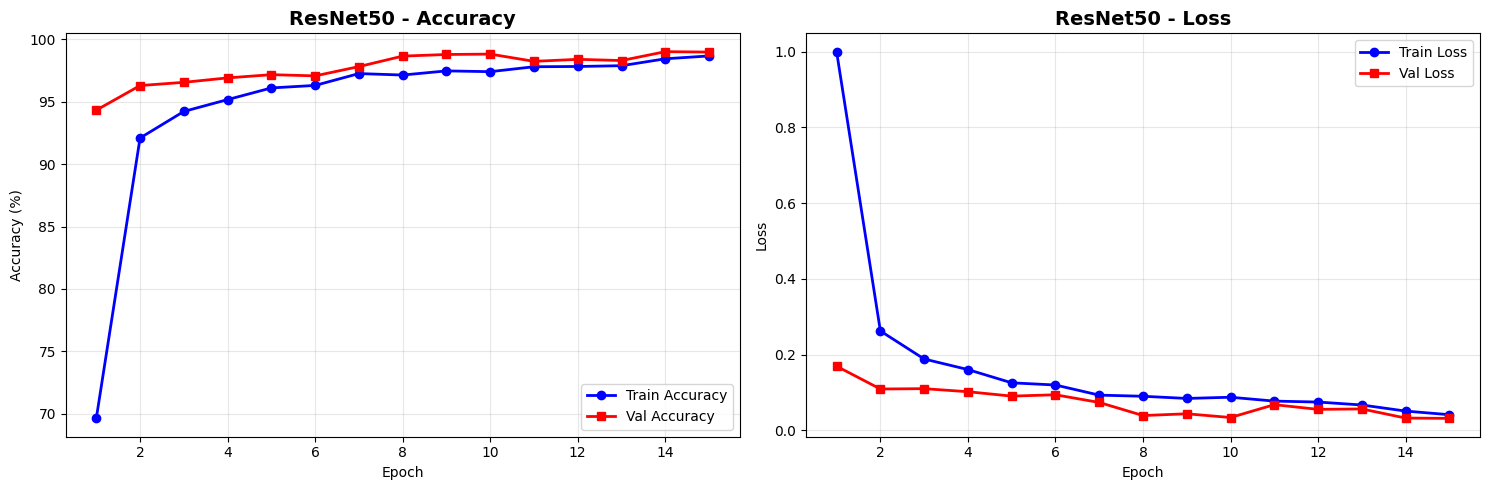

   ✅ Saved: resnet50_confusion_matrix.png


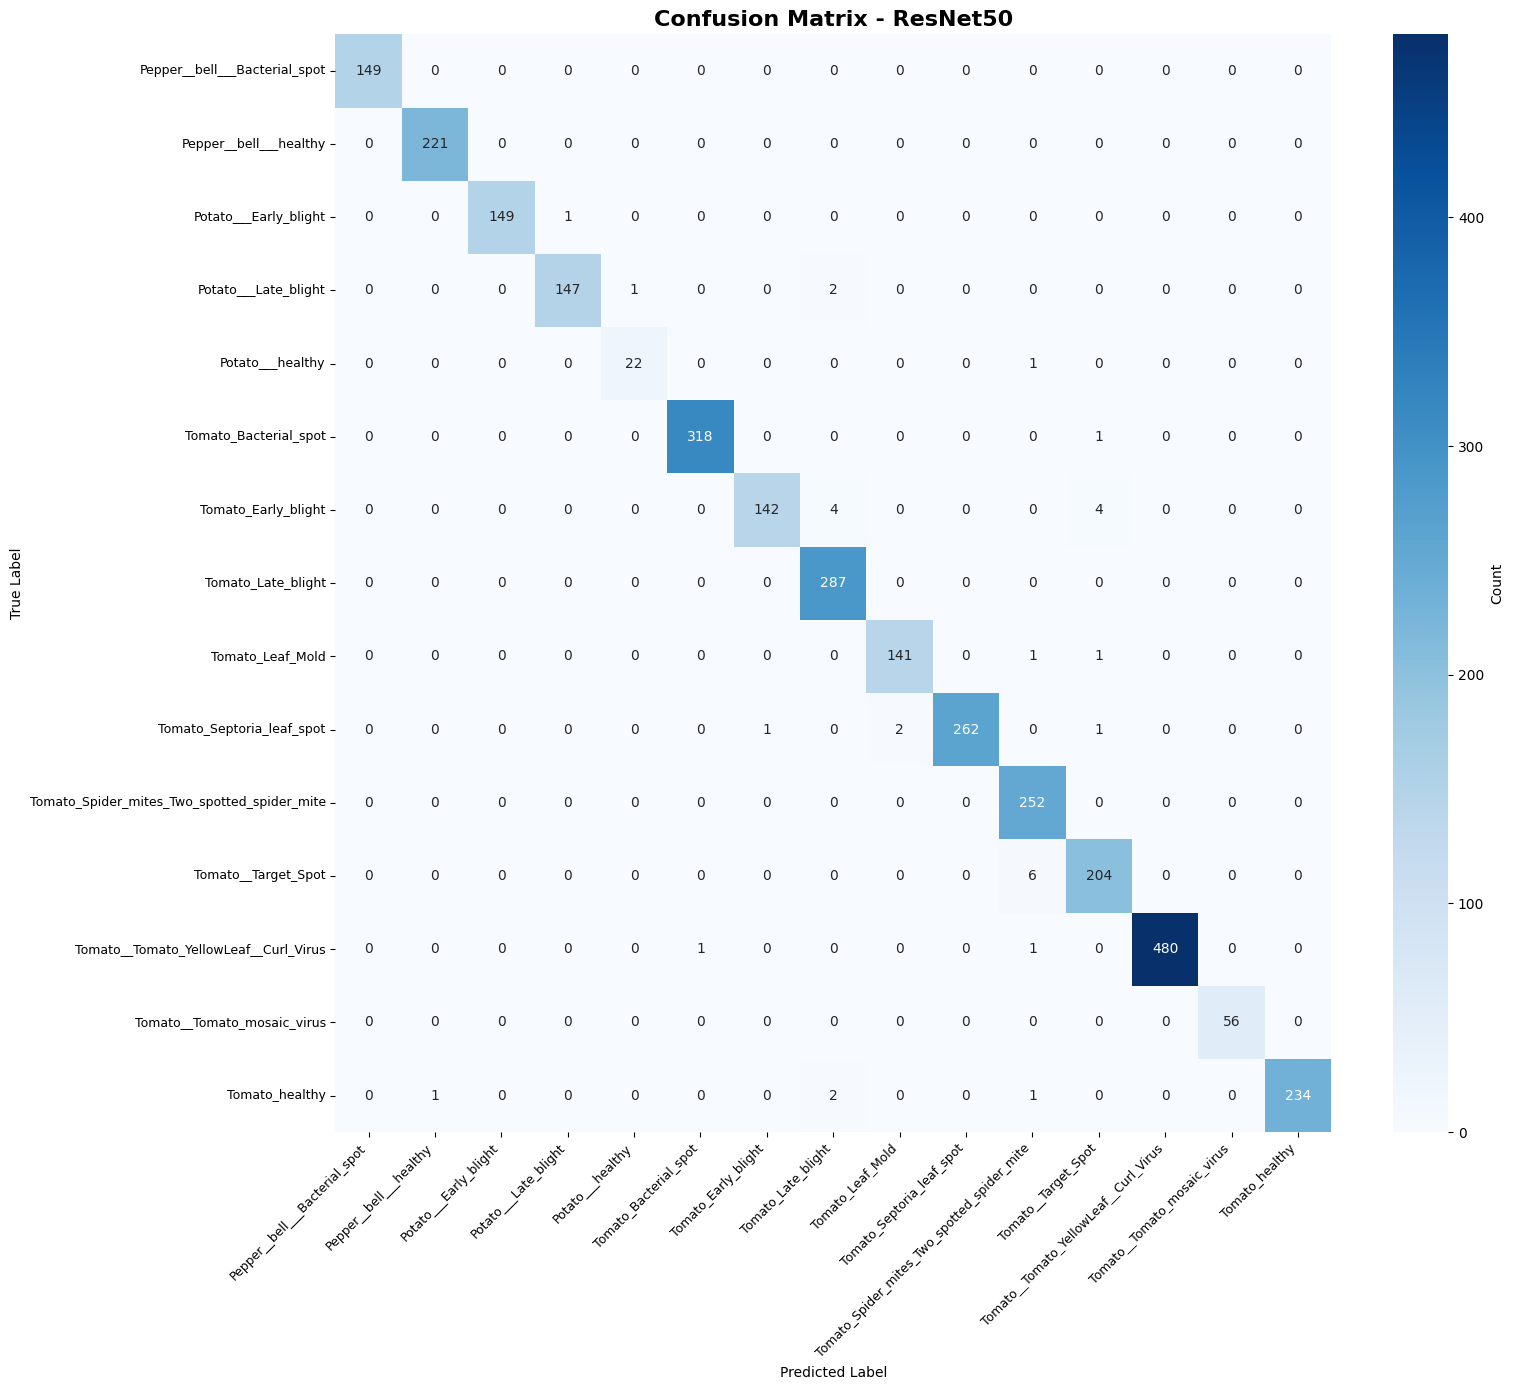


💾 Saving model and results...
   ✅ Saved model: /content/drive/MyDrive/SmartFarming/models/disease_model_resnet50.pth
   ✅ Saved metadata: /content/drive/MyDrive/SmartFarming/models/disease_model_metadata.json
   ✅ Saved history: /content/drive/MyDrive/SmartFarming/models/training_history.csv
   ✅ Saved visualizations to Drive

✅ RESNET50 TRAINING COMPLETE!
🏆 Test Accuracy: 98.97%
⏱️  Training Time: 33.10 minutes

📥 All files saved to Google Drive:
   /content/drive/MyDrive/SmartFarming/models
You can download them from there!


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm.notebook import tqdm

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    'img_size': 224,
    'batch_size': 64,  # Large batch size with GPU
    'epochs': 15,      # More epochs with GPU
    'learning_rate': 0.0001,
    'num_workers': 2
}

print("\n⚙️  Configuration:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

# ============================================================================
# DATASET CLASS
# ============================================================================

class PlantDiseaseDataset(Dataset):
    """Custom Dataset for Plant Disease Images"""

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Get class names
        self.class_names = sorted([d.name for d in self.root_dir.iterdir() if d.is_dir()])
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.class_names)}

        # Collect all image paths
        print(f"   Loading images from {self.root_dir.name}...")
        for class_name in self.class_names:
            class_dir = self.root_dir / class_name
            # Support both .JPG and .jpg extensions
            for ext in ['*.JPG', '*.jpg', '*.jpeg', '*.JPEG', '*.png', '*.PNG']:
                for img_path in class_dir.glob(ext):
                    self.image_paths.append(img_path)
                    self.labels.append(self.class_to_idx[class_name])

        print(f"      Found {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return a blank image if error
            image = Image.new('RGB', (224, 224), color='black')

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# ============================================================================
# DATA LOADERS
# ============================================================================

print("\n📦 Setting up data loaders...")

# Transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = PlantDiseaseDataset(TRAIN_DIR, train_transform)
val_dataset = PlantDiseaseDataset(VAL_DIR, test_transform)
test_dataset = PlantDiseaseDataset(TEST_DIR, test_transform)

class_names = train_dataset.class_names
num_classes = len(class_names)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"\n✅ Data loaded:")
print(f"   Train: {len(train_dataset):,} images")
print(f"   Val:   {len(val_dataset):,} images")
print(f"   Test:  {len(test_dataset):,} images")
print(f"   Classes: {num_classes}")
print(f"   Batches per epoch: {len(train_loader)}")

# ============================================================================
# MODEL: RESNET50
# ============================================================================

print("\n🏗️  Building ResNet50 model...")

# Load pretrained ResNet50
model = models.resnet50(weights='IMAGENET1K_V1')

# Freeze early layers (optional - faster training)
for param in list(model.parameters())[:-30]:
    param.requires_grad = False

# Replace final classification layer
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

model = model.to(device)

print(f"   ✅ Model built and moved to {device}")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ============================================================================
# TRAINING SETUP
# ============================================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=CONFIG['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n🏋️  Training ResNet50...")
print("="*70)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0
best_model_state = None
patience_counter = 0
max_patience = 5

start_time = time.time()

for epoch in range(CONFIG['epochs']):
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
    print("-"*70)

    # ========================================================================
    # TRAINING PHASE
    # ========================================================================
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc='Training', leave=False)
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        train_bar.set_postfix({
            'loss': f'{train_loss/(train_bar.n+1):.4f}',
            'acc': f'{100.*train_correct/train_total:.2f}%'
        })

    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total

    # ========================================================================
    # VALIDATION PHASE
    # ========================================================================
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc='Validation', leave=False)
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

            val_bar.set_postfix({
                'loss': f'{val_loss/(val_bar.n+1):.4f}',
                'acc': f'{100.*val_correct/val_total:.2f}%'
            })

    val_loss /= len(val_loader)
    val_acc = 100. * val_correct / val_total

    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"✅ New best model! Val Acc: {best_val_acc:.2f}%")
    else:
        patience_counter += 1
        if patience_counter >= max_patience:
            print(f"⚠️  Early stopping triggered (patience={max_patience})")
            break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

train_time = time.time() - start_time

print(f"\n{'='*70}")
print(f"✅ Training completed in {train_time/60:.2f} minutes")
print(f"   Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"{'='*70}")

# ============================================================================
# TEST EVALUATION
# ============================================================================

print("\n🧪 Evaluating on test set...")

model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)

test_accuracy = accuracy_score(y_true, y_pred)

print(f"\n{'='*70}")
print(f"🏆 FINAL RESULTS")
print(f"{'='*70}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Best Val Accuracy: {best_val_acc:.2f}%")
print(f"Training Time: {train_time/60:.2f} minutes")
print(f"\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n📊 Creating visualizations...")

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs_range = range(1, len(history['train_acc']) + 1)

ax1.plot(epochs_range, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2, marker='o')
ax1.plot(epochs_range, history['val_acc'], 'r-', label='Val Accuracy', linewidth=2, marker='s')
ax1.set_title('ResNet50 - Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2, marker='o')
ax2.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2, marker='s')
ax2.set_title('ResNet50 - Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('resnet50_training_curves.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: resnet50_training_curves.png")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - ResNet50', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('resnet50_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: resnet50_confusion_matrix.png")
plt.show()

# ============================================================================
# SAVE MODEL & RESULTS
# ============================================================================

print("\n💾 Saving model and results...")

# Save to Google Drive
SAVE_DIR = Path('/content/drive/MyDrive/SmartFarming/models')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Save model
model_path = SAVE_DIR / 'disease_model_resnet50.pth'
torch.save(model.state_dict(), model_path)
print(f"   ✅ Saved model: {model_path}")

# Save metadata
metadata = {
    'model_name': 'ResNet50',
    'test_accuracy': float(test_accuracy),
    'val_accuracy': float(best_val_acc / 100),
    'train_time_minutes': float(train_time / 60),
    'num_classes': num_classes,
    'classes': class_names,
    'image_size': [CONFIG['img_size'], CONFIG['img_size']],
    'epochs_trained': len(history['train_acc']),
    'config': CONFIG,
    'training_date': '2025-11-17'
}

metadata_path = SAVE_DIR / 'disease_model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"   ✅ Saved metadata: {metadata_path}")

# Save training history
history_df = pd.DataFrame(history)
history_path = SAVE_DIR / 'training_history.csv'
history_df.to_csv(history_path, index=False)
print(f"   ✅ Saved history: {history_path}")

# Copy visualizations to Drive
import shutil
shutil.copy('resnet50_training_curves.png', SAVE_DIR / 'resnet50_training_curves.png')
shutil.copy('resnet50_confusion_matrix.png', SAVE_DIR / 'resnet50_confusion_matrix.png')
print(f"   ✅ Saved visualizations to Drive")

print("\n" + "="*70)
print("✅ RESNET50 TRAINING COMPLETE!")
print("="*70)
print(f"🏆 Test Accuracy: {test_accuracy*100:.2f}%")
print(f"⏱️  Training Time: {train_time/60:.2f} minutes")
print(f"\n📥 All files saved to Google Drive:")
print(f"   {SAVE_DIR}")
print("You can download them from there!")
print("="*70)
